In [66]:
import pandas as pd  
import seaborn as sns
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import folium 

ModuleNotFoundError: No module named 'folium'

In [3]:
datos  = pd.read_csv('DataAWS.csv')
datos.columns

Index(['periodo', 'estu_tipodocumento', 'estu_consecutivo',
       'cole_area_ubicacion', 'cole_bilingue', 'cole_calendario',
       'cole_caracter', 'cole_cod_dane_establecimiento', 'cole_cod_dane_sede',
       'cole_cod_depto_ubicacion', 'cole_cod_mcpio_ubicacion',
       'cole_codigo_icfes', 'cole_depto_ubicacion', 'cole_genero',
       'cole_jornada', 'cole_mcpio_ubicacion', 'cole_naturaleza',
       'cole_nombre_establecimiento', 'cole_nombre_sede',
       'cole_sede_principal', 'estu_cod_depto_presentacion',
       'estu_cod_mcpio_presentacion', 'estu_cod_reside_depto',
       'estu_cod_reside_mcpio', 'estu_depto_presentacion', 'estu_depto_reside',
       'estu_estadoinvestigacion', 'estu_estudiante', 'estu_fechanacimiento',
       'estu_genero', 'estu_mcpio_presentacion', 'estu_mcpio_reside',
       'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad',
       'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre',
       'fami_estratovivienda', 'fami_perso

In [47]:
columns_imp["cole_caracter"].unique()

<StringArray>
['TÉCNICO/ACADÉMICO', 'TÉCNICO', 'ACADÉMICO', 'NO APLICA', nan]
Length: 5, dtype: str

In [62]:
list = ["cole_bilingue","desemp_ingles","punt_ingles","punt_lectura_critica","punt_global","cole_caracter","cole_mcpio_ubicacion"]

columns_imp = datos[["cole_bilingue","desemp_ingles","punt_ingles","punt_lectura_critica","punt_global","cole_caracter","cole_mcpio_ubicacion"]]
# MAPEO DE VARIABLES CATEGORICAS - DISCRETAS 
dict_map = {
    "bili": {"N":0,"S": 1,"NaN":-1},
    "desemp": {"A-": 0,"A1":1,"A2":2,"B1":3,"B+": 4,"NaN":-1},
    "caract": {"TÉCNICO/ACADÉMICO": "Comb","TÉCNICO": "Tec","ACADÉMICO":"Acad", "NO APLICA": "NA"}
}

#columns_imp["cole_bilingue"] =columns_imp["cole_bilingue"].map(dict_map["bili"])
#columns_imp["desemp_ingles"] =columns_imp["desemp_ingles"].map(dict_map["desemp"])
columns_imp["cole_caracter"] =columns_imp["cole_caracter"].map(dict_map["caract"])
data = pd.DataFrame(columns_imp)
data

,cole_bilingue,desemp_ingles,punt_ingles,punt_lectura_critica,punt_global,cole_caracter,cole_mcpio_ubicacion
0,N,A2,61.00,56.0,295.0,Comb,DUITAMA
1,N,A1,43.00,NaN,NaN,Comb,SORA
2,N,A-,38.53,NaN,NaN,Tec,TASCO
3,N,A1,52.00,54.0,277.0,Comb,SOGAMOSO
4,N,A1,55.00,47.0,254.0,Tec,TURMEQUE
...,...,...,...,...,...,...,...
215229,NaN,A-,47.00,50.0,235.0,Acad,DUITAMA
215230,N,A1,50.00,NaN,NaN,Comb,SORACÁ
215231,N,B1,76.00,63.0,344.0,Acad,TUNJA
215232,S,A-,42.00,NaN,NaN,Acad,SÁCHICA


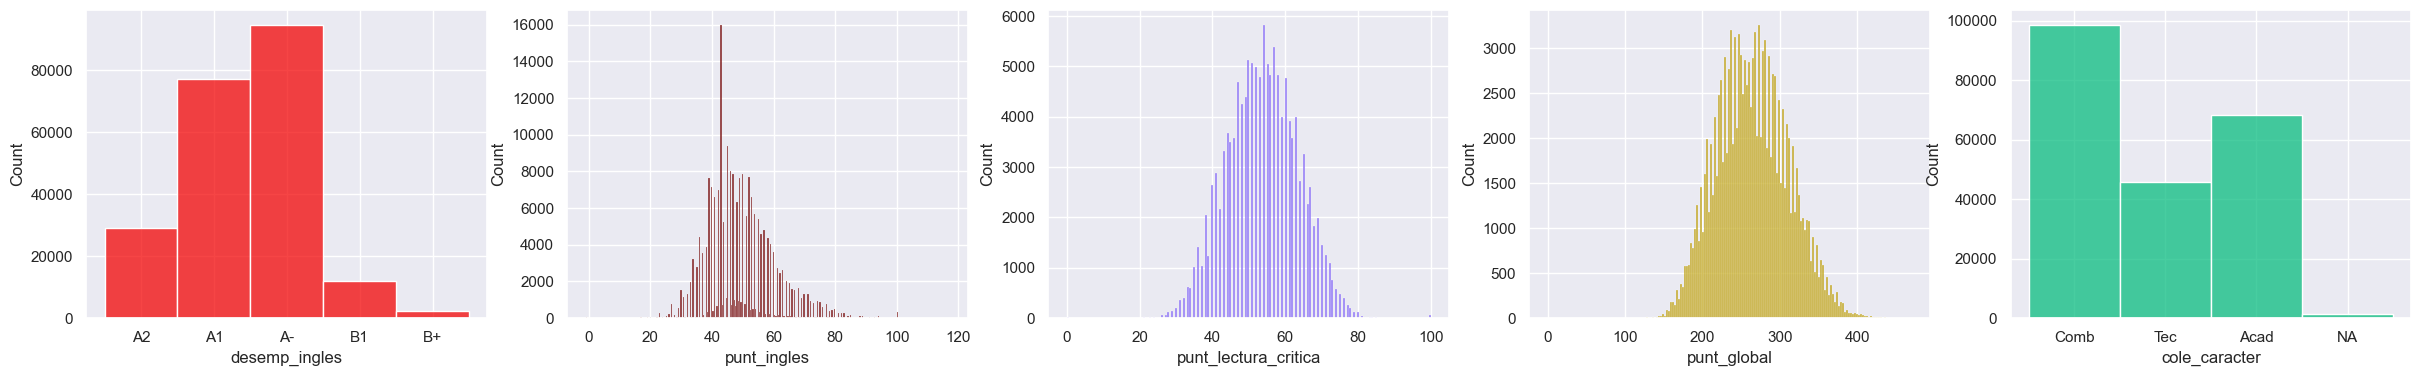

In [63]:
def decriptive_stats(data_convert,num_cols = 0,w=0,l=0,lan=[]):

    sns.set_theme(style="darkgrid")

    num_cols = num_cols  # numeros filas
    num_rows = (len(data_convert.columns[1:]) + num_cols - 1) // num_cols  

    fig, axs = plt.subplots(num_rows, num_cols, figsize=(w, l * num_rows))
    axs = axs.flatten()  

    colors = [
        "#F30606", "#750808", "#8366F8", "#BD9F0A", "#0ABD80", "#753508", "#CC19F0", "#086B75",
        "#F466F8", "#F86673", "#107653", "#FF9926", "#087515", "#EE2510", "#19F0C9", "#750860",
        "#1988F0", "#E33F22", "#44E8FF", "#F0E619", "#C1FF44", "#60f2bb", "#0fdd99", "#b505f7",
        "#d4362e", "#83970c", "#9b2b11", "#4e19ae", "#701f7e", "#09e842", "#8b2ff7", "#98eb17",
        "#4C4CFF", "#BE1D00", "#24cd13", "#fcc533", "#01d0b4"
    ]

    # Grafico
    for i, col in enumerate(data_convert.columns[1:]):
        sns.histplot(data=data_convert, x=col, kde=False, color=colors[i % len(colors)], ax=axs[i])
        
    # Esconder graficos no usados
    for j in range(i + 1, len(axs)):
        axs[j].axis('off')
    
    return plt.show()

graph_data = data.drop(columns=data.columns[-1])
decriptive_stats(graph_data,5,30,4)

In [65]:
columns_imp["cole_bilingue"] =columns_imp["cole_bilingue"].map(dict_map["bili"])
columns_imp["desemp_ingles"] =columns_imp["desemp_ingles"].map(dict_map["desemp"])
columns_imp["cole_caracter"] =columns_imp["cole_caracter"].map(dict_map["caract"])
data = pd.DataFrame(columns_imp)
